# Evaluation
In this notebook, evaluation metrics are computed for the four models 
built earlier, to visualize and quantify how model performance changes 
depending on the aggressiveness of text cleaning applied during 
preprocessing.

Each model is evaluated using:
- **Precision**: of every email the model labeled as spam, how many 
  actually were spam.
- **Recall**: of every email that actually was spam, how many did the 
  model correctly catch.
- **F1**: the harmonic mean of precision and recall, balancing both 
  into a single score.
- **Accuracy**: the overall proportion of correct predictions (true 
  positives and true negatives) out of all predictions made.

This is done for each model, ranging from most aggressive cleaning 
(v1: stopwords, noise words, and placeholder tokens all removed) to 
least aggressive cleaning (v4: punctuation stripping only).

In [33]:
# Imports 
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Testing dataset
A set of spam and ham emails held out from the original dataset before training (the model has never seen these emails). The test set maintains a class balance similar to the training set, 53.4% ham vs 46.6% spam, compared to 52.6% ham / 47.4% spam in training to better simulate a realistic evaluation environment rather than a artificially balanced one.

In [61]:
# load testing data set and drop null values
df = pd.read_csv("../data/raw/testing_dataset.csv")
df = df.dropna(subset=["text"])

In [62]:
df.head()

,label,text
0,Spam,ba eb cescapenumber ce cescapenumber eescapenu...
1,Ham,louise :\r\nis enron ready for this ? i think ...
2,Spam,force field of the aristocratic families of gr...
3,Spam,is your credit a mess ?\r\ndo you want perfect...
4,Ham,dear r list members i have been a user of spss...


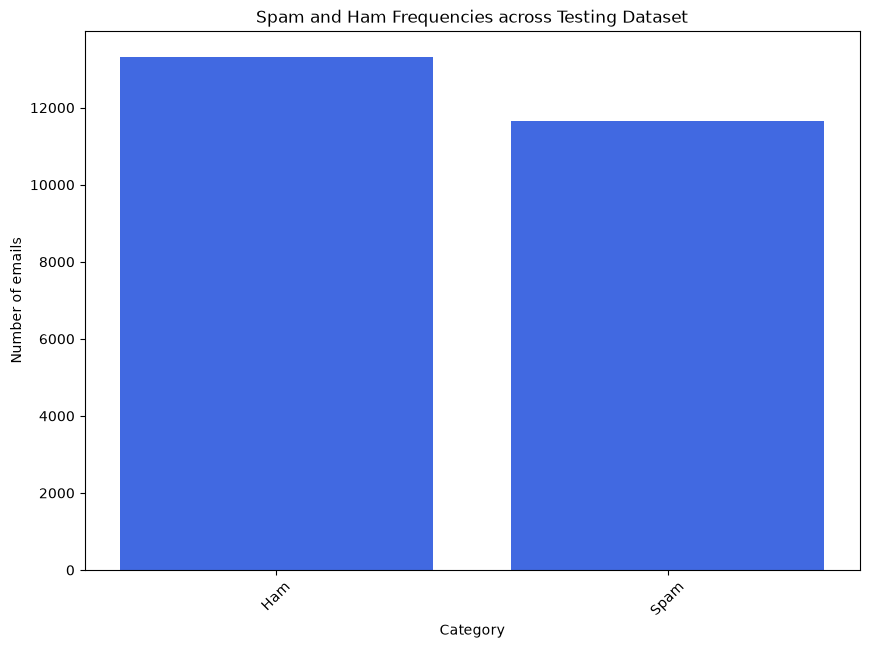

Test set spam: 11645 (46.6%)
Test set ham: 13324 (53.4%)


In [63]:
category_counts = df['label'].value_counts()
plt.figure(figsize=(10,7))
plt.bar(category_counts.index, category_counts.values, color='royalblue')
plt.title('Spam and Ham Frequencies across Testing Dataset')
plt.xticks(rotation=45) # Rotate labels to avoid overlap
plt.ylabel("Number of emails")
plt.xlabel("Category")
plt.show()

train_counts = df["label"].value_counts()
train_total = len(df)

test_counts = df["label"].value_counts()
test_total = len(df)
print(f"Test set spam: {test_counts['Spam']} ({test_counts['Spam']/test_total:.1%})")
print(f"Test set ham: {test_counts['Ham']} ({test_counts['Ham']/test_total:.1%})")


In [64]:
# clean and tokanize
pattern = re.compile(r'[^a-zA-Z\s]+')
noise_pattern = re.compile(r'escapenumber|escapelong', re.IGNORECASE)
stopwords = {'y', 'did', 'i', 'again', "hadn't", 'my', 'over', 'too', 'here', "that'll", 'couldn', 'than', "they've", 'same', "she's", 'they', 'doing', 'if', 'down', "don't", 'out', 'no', 'her', 're', 'such', 't', "i've", 'only', 'was', 'shouldn', "they'd", 'won', 'more', 'needn', 'do', "shouldn't", "wasn't", "aren't", 'aren', 'how', 'shan', 'doesn', 'few', 'll', 'myself', "couldn't", "he'd", 'other', 'wasn', 'his', 'on', 'these', 'both', "didn't", 'you', "you've", 'their', 'what', "you'd", 'being', 'by', 'been', 's', 'ain', 'why', 'where', 'until', 'as', 'off', 'after', 'is', 'be', 'below', 'hasn', 'yours', 'we', 'has', 'own', 've', 'haven', 'whom', 'wouldn', 'hers', "we'd", 'between', 'o', "he's", 'have', 'herself', 'does', 'now', "shan't", 'don', 'in', 'so', 'from', 'a', 'under', 'further', 'those', 'me', 'most', "weren't", 'against', 'its', 'she', 'at', "you'll", 'yourself', "i'll", 'm', 'once', 'mustn', 'while', 'should', 'ours', 'didn', 'then', 'when', 'that', 'were', "it'd", 'which', 'above', 'all', "doesn't", "mustn't", "she'd", "it's", 'before', 'of', 'and', 'weren', "she'll", 'our', 'will', 'isn', "i'm", 'had', 'to', 'the', 'through', 'with', 'there', 'during', 'or', "haven't", 'himself', 'it', 'theirs', "wouldn't", 'each', 'not', 'just', 'this', "we'll", "he'll", "needn't", "we've", 'ourselves', 'about', "isn't", 'your', 'nor', 'because', 'can', 'he', 'am', "i'd", "should've", 'any', 'd', 'some', 'having', 'ma', 'itself', 'into', "we're", "hasn't", "they'll", 'who', 'are', 'but', 'themselves', "mightn't", "it'll", 'very', 'for', 'hadn', "you're", 'him', 'them', 'an', "they're", 'mightn', "won't", 'yourselves', 'up'}
NOISE_WORDS = {"subject", "pm", "org", "com", "http", "www"}

def clean(email: str) -> list[str]:
    email = noise_pattern.sub('', email)
    words = email.lower().split()
    words = [pattern.sub('', w) for w in words]
    words = [
        w for w in words
        if w and len(w) > 1 and w not in stopwords and w not in NOISE_WORDS
    ]
    return words

## Prediction revamped
Prediction performance was improved by summing each class's 
log-likelihoods directly at the index of each word actually present in 
the email, rather than constructing a full document vector (mostly 
zeros, one entry per vocabulary word) and computing a dot product 
against it. Since a typical email only contains a small fraction of the 
full vocabulary, this avoids allocating and multiplying against a large, 
mostly-empty array for every prediction touching only the words that 
are actually present. This performs substantially faster than the 
original vectorized approach used in the training notebook[, reducing 
evaluation time across all four models from approximately ~2 minutes to 
~30 seconds].

In [65]:
# Prediction
def load_model(path="../models/modelv1.json"):
    with open(path, "r") as f:
        model = json.load(f)
    vocab = model["vocab"]
    log_prior_s, log_prior_h = np.array(model["log_priors"])
    log_likelihoods = np.array(model["log_likelihoods"])
    return vocab, log_prior_s, log_prior_h, log_likelihoods

def predict(email, vocab, log_prior_s, log_prior_h, log_likelihoods):
    cleaned = clean(email)
    log_post_spam = log_prior_s
    log_post_ham = log_prior_h

    for word in cleaned:
        index = vocab.get(word)
        if index is None:
            continue
        log_post_spam += log_likelihoods[0][index]
        log_post_ham += log_likelihoods[1][index]

    return "spam" if log_post_spam > log_post_ham else "ham"

In [66]:
vocab, log_prior_s, log_prior_h, log_likelihoods = load_model()

In [75]:
# compute the true positives, true negatives, false positives and false negavitves 
# negative is ham and positive is spam 
# tp are emails classified as spam and are spam 
# tn are emails classified as ham and are ham 
# fp are emails classified as spam but are ham 
# fn are emails classified as ham but are spam 

def confusion(model_path, test_df): 
    vocab, log_prior_s, log_prior_h, log_likelihoods = load_model(model_path)
    tp, tn, fp, fn = 0, 0, 0, 0

    for index, row in test_df.iterrows():
        label = row["label"].lower()
        email = row["text"]

        prediction = predict(email, vocab, log_prior_s, log_prior_h, log_likelihoods)

        match (label, prediction):
            case ("spam", "spam"):
                tp += 1
            case ("ham", "ham"):
                tn += 1
            case ("ham", "spam"):
                fp += 1
            case ("spam", "ham"):
                fn += 1
                
    confusion_matrix = np.vstack([[tp, fn], [fp, tn]])
    
    return confusion_matrix, tp, tn, fp, fn, len(vocab)

In [76]:
# compute precision, recall and F1 for each model 
model_performance = []
version = 0
models = ["../models/modelv1.json", "../models/modelv2.json", "../models/modelv3.json", "../models/modelv4.json"]

for path in models:
    version += 1
    confusion_matrix, tp, tn, fp, fn, vocab_size = confusion(path, df)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2*((precision * recall) / (precision + recall))
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    model_performance.append({
        "Model": f"version {version}",
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Accuracy": accuracy,
        "Vocab size": vocab_size
    })


In [77]:
results_df = pd.DataFrame(model_performance)
results_df

,Model,Precision,Recall,F1-score,Accuracy,Vocab size
0,version 1,0.976039,0.951481,0.963604,0.966478,374545
1,version 2,0.975870,0.951567,0.963565,0.966438,374551
2,version 3,0.978570,0.941091,0.959464,0.962914,374696
3,version 4,0.981686,0.929841,0.955061,0.959189,387229


## Results
As cleaning becomes less aggressive (v1 to v4), vocabulary size grows 
to include more stopwords, noise words, and placeholder tokens. 
Precision increases slightly across this range, meaning the model mislabels spam less frequently, but recall drops more noticeably, eaning the model misses a growing share of actual spam emails. This trade off produces a small but consistent decline in both accuracy and F1 as cleaning decreases, suggesting that a larger, noisier vocabulary makes the model marginally more conservative about labeling emails as spam, at the cost of catching fewer of them.

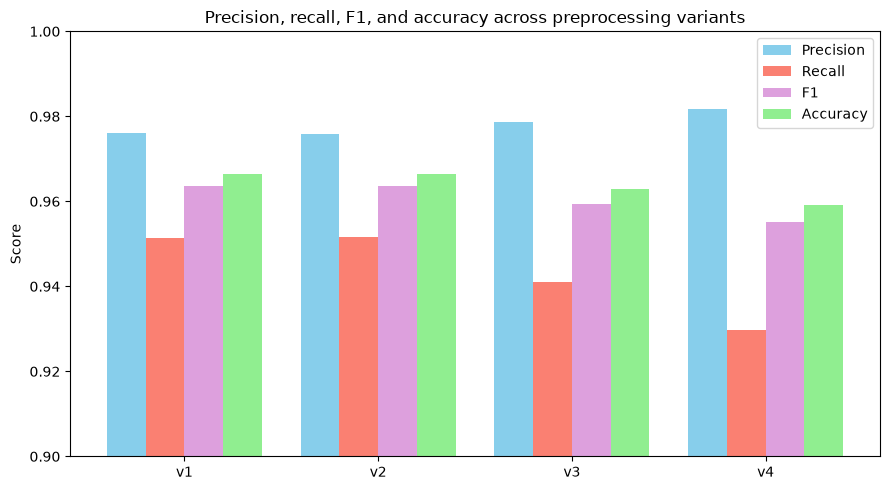

In [70]:
x = np.arange(len(results_df))
width = 0.2  # narrower, since you're fitting 4 bars per group instead of 3

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 1.5*width, results_df["Precision"], width, label="Precision", color="skyblue")
ax.bar(x - 0.5*width, results_df["Recall"], width, label="Recall", color="salmon")
ax.bar(x + 0.5*width, results_df["F1-score"], width, label="F1", color="plum")
ax.bar(x + 1.5*width, results_df["Accuracy"], width, label="Accuracy", color="lightgreen")

ax.set_xticks(x)
ax.set_xticklabels(["v1", "v2", "v3", "v4"])
ax.set_ylim(0.9, 1.0)
ax.set_ylabel("Score")
ax.set_title("Precision, recall, F1, and accuracy across preprocessing variants")
ax.legend()

plt.tight_layout()
plt.show()